In [17]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
borrowers = pd.read_csv('../data/borrower_profiles_clean.csv')
loans = pd.read_csv('../data/loan_applications_clean.csv')

# Merge
df=loans.merge(borrowers,on='borrower_id')

print(df.shape)
df.head

(601, 22)


<bound method NDFrame.head of       loan_id borrower_id application_date      loan_purpose  loan_amount  \
0    LN-00001    BRW-0001       2024-01-08          Vacation      16100.0   
1    LN-00002    BRW-0001       2024-08-13    Major Purchase       5600.0   
2    LN-00003    BRW-0002       2025-06-28            Moving      44700.0   
3    LN-00004    BRW-0003       2025-05-18         Auto Loan       9200.0   
4    LN-00005    BRW-0004       2025-03-24            Moving      11200.0   
..        ...         ...              ...               ...          ...   
596  LN-00597    BRW-0497       2025-02-06           Wedding      29100.0   
597  LN-00598    BRW-0498       2024-04-19            Moving       4600.0   
598  LN-00599    BRW-0499       2024-02-24         Education       7800.0   
599  LN-00600    BRW-0500       2024-11-14  Medical Expenses      26400.0   
600  LN-00601    BRW-0500       2024-05-03           Wedding       7500.0   

     term_months  interest_rate  monthly_paym

In [19]:
total_loans=len(df)
total_defaults=df['defaulted'].sum()
default_rate=(total_defaults/total_loans)*100

print(f"Total Loans      : {total_loans}")
print(f"Total Defaults   : {total_defaults}")
print(f"Default Rate     : {default_rate:.2f}%")
print(f"Company Target   : 12.00%")
print(f"Gap              : {default_rate - 12:.2f}% above target")

Total Loans      : 601
Total Defaults   : 146
Default Rate     : 24.29%
Company Target   : 12.00%
Gap              : 12.29% above target


In [20]:
df['score_bucket']=pd.cut(
    df['credit_score'],
    bins=[519,599,649,699,749,850],
    labels=['520-599','600-649','650-699','700-749','750+']
)

score_analysis=df.groupby('score_bucket',observed=True).agg(
    total_loans=('defaulted','count'),
    defaults=('defaulted','sum')
).reset_index()

score_analysis['default_rate%']=(score_analysis['defaults']/score_analysis['total_loans']*100).round(2)
print(score_analysis)



  score_bucket  total_loans  defaults  default_rate%
0      520-599          116        57          49.14
1      600-649           93        27          29.03
2      650-699           75        21          28.00
3      700-749           86        14          16.28
4         750+          231        27          11.69


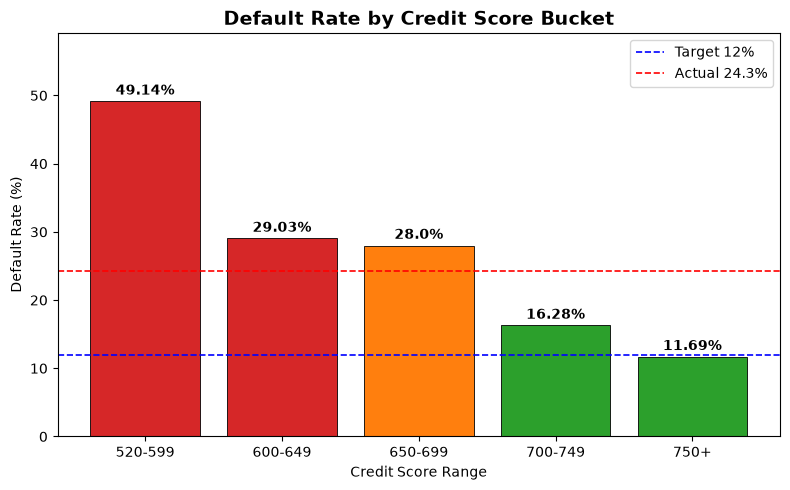

In [22]:
# Chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(score_analysis['score_bucket'], score_analysis['default_rate%'],
              color=['#d62728','#d62728','#ff7f0e','#2ca02c','#2ca02c'],
              edgecolor='black', linewidth=0.6)

ax.axhline(12, color='blue', linestyle='--', linewidth=1.2, label='Target 12%')
ax.axhline(default_rate, color='red', linestyle='--', linewidth=1.2, label=f'Actual {default_rate:.1f}%')

for bar, val in zip(bars, score_analysis['default_rate%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Default Rate by Credit Score Bucket', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Score Range')
ax.set_ylabel('Default Rate (%)')
ax.legend()
ax.set_ylim(0, score_analysis['default_rate%'].max() + 10)
plt.tight_layout()
plt.savefig('../reports/chart1_credit_score_default.png', dpi=150)
plt.show()